In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_excel('demand_dataset.xlsx')
df = df[df['SKU'] == 'SKU-1001']
df['Date'] = pd.to_datetime(df['Date'])
df['Month'] = df['Date'].dt.to_period('M')

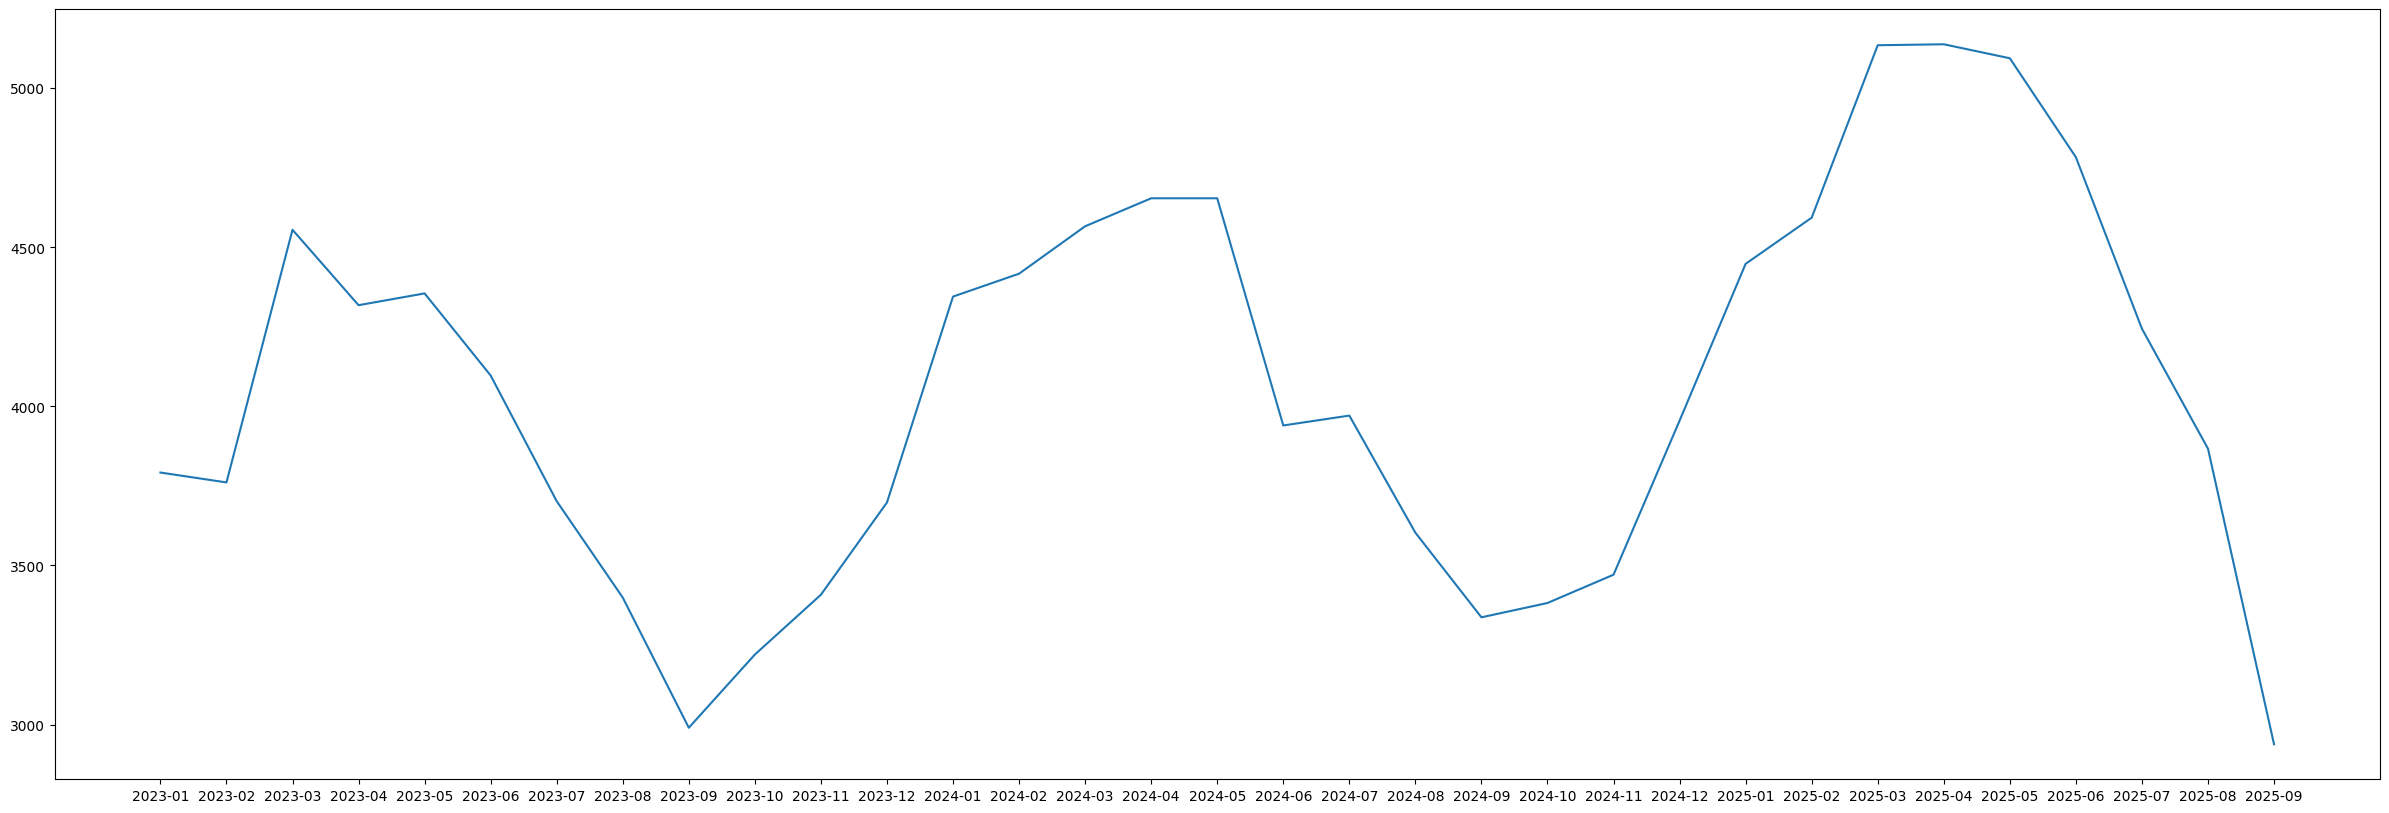

In [10]:
demand_by_month = df.groupby('Month')['Demand'].sum().reset_index()

plt.figure(figsize=[30,10])
plt.plot(demand_by_month['Month'].astype(str), demand_by_month['Demand'])
plt.show()

In [11]:
demand_by_month

,Month,Demand
0,2023-01,3792
1,2023-02,3761
2,2023-03,4555
3,2023-04,4318
4,2023-05,4355
5,2023-06,4097
6,2023-07,3702
7,2023-08,3399
8,2023-09,2990
9,2023-10,3220


In [12]:
df = df.groupby(['Date', 'Month'])['Demand'].sum().reset_index()

## Demand forecast (Prophet)
The forecast is used **not** as a source for day-by-day resampling, but for two purposes:
1. Estimating total demand over the horizon — an input for the EOQ calculation.
2. Defining the range used to select historical periods with a similar demand pattern for the Bootstrap simulation.

Day-level resampling directly from the forecast is deliberately avoided: Prophet's daily 
confidence intervals don't account for business constraints (for example, they can produce 
a negative lower bound when historical values include zeros), which makes this approach 
unsuitable for realistic demand simulation.

In [13]:
from prophet import Prophet


prophet_df = df[['Date', 'Demand']].copy()

prophet_df['Date'] = pd.to_datetime(prophet_df['Date'])

prophet_df = prophet_df.rename(columns={'Date': 'ds', 'Demand': 'y'})


model = Prophet(
    growth='linear',

    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False,

    changepoint_prior_scale=0.08,

    seasonality_prior_scale=10,

    interval_width=0.95
)


model.add_seasonality( name='monthly', period=30.5, fourier_order=5)

model.fit(prophet_df)

future = model.make_future_dataframe( periods=31, freq='D')

forecast = model.predict(future)

forecast = forecast[['ds','yhat','yhat_lower','yhat_upper']].tail(31)
print(f"yhat_lower {forecast['yhat_lower'].sum()} , yhat {forecast['yhat'].sum()}, yhat_upper {forecast['yhat_upper'].sum()}")

23:21:23 - cmdstanpy - INFO - Chain [1] start processing
23:21:23 - cmdstanpy - INFO - Chain [1] done processing


yhat_lower 2486.78681000109 , yhat 3697.6873795688844, yhat_upper 4905.573632978532


## EOQ — economic order quantity
EOQ is calculated based on total forecasted demand over the horizon 
(`forecast_predict`), logistics cost, and per-unit holding cost. 
EOQ sets the replenishment quantity, but does not solve the problem of choosing 
the Reorder Point — that's what the simulation below does.

In [14]:
import math

def EOQ(forecast_units, logistics_cost, warehousing_save_by_unit_cost):
    EOQ_formula = math.sqrt((2*forecast_units*logistics_cost)/warehousing_save_by_unit_cost)
    return EOQ_formula
    
EOQ_calulated = EOQ(forecast['yhat'].sum(), 500, 1.55)
print(EOQ_calulated)

1544.5403073446103


## Period selection for Bootstrap resampling
For simulating daily demand, historical periods are used whose 
actual demand falls within the range 
`yhat_lower — yhat_upper`. 
This preserves the real character of demand instead of 
relying on the forecast's parametric uncertainty.

I chose to select only the periods where the forecast is closest to yhat. 
Selected periods: 2023-07, 2023-12, 2024-08, 2023-02, 2025-08, 2023-08.

In [15]:
import numpy as np

np.random.seed(42)

Q_init = 1352
EOQ = EOQ_calulated
LeadTime_init = 5

waiting_res_SLA_down_gr = 95
waiting_res_SLA_upper_gr = 100

def run_simulation(ROP_value, n_iter=1000, logistics_cost=500, storage_costs_units_by_day=0.05):
    StockOut_percent = []
    StockOut_arr_bootstrap = []
    Costs_arr_bootstrap = []
    Fill_Rate = None
    Total_demand = []
    
    ################################################### 
    for __ in range(n_iter):
        Q = Q_init
        ROP = ROP_value
        LeadTime = LeadTime_init
        StockOut_arr = []
        costs = 0
        flag_workON = True
        flag_creatingOrder = False

        for _ in range(31):
            satisfy_demand = False
            
            demand = np.random.choice(
                df[df['Month'].isin(pd.PeriodIndex(['2023-07','2023-12','2024-08','2023-02','2025-08','2023-08'], freq='M'))]['Demand'], 
                replace=True, 
                size=1)[0]

            Total_demand.append(demand)
            
            costs += storage_costs_units_by_day*Q

            if flag_workON:
                Q -= demand
                satisfy_demand = True
                if Q <= 0:
                    StockOut_arr.append(abs(Q))
                    Q = 0
                    flag_workON = False

            if Q <= ROP:
                if not flag_creatingOrder:
                    LeadTime -= 1
                    flag_creatingOrder = True
                    costs += logistics_cost
                else:
                    LeadTime -= 1

                if LeadTime == 0:
                    Q += EOQ
                    flag_creatingOrder = False
                    flag_workON = True
                    LeadTime = LeadTime_init
                    if not satisfy_demand:
                        Q -= demand
                        satisfy_demand = True
                    if Q <= 0:
                        StockOut_arr.append(abs(Q))
                        Q = 0
                        flag_workON = False
                    if Q <= ROP:
                        LeadTime -= 1
                        flag_creatingOrder = True

            if not flag_workON and not satisfy_demand:
                StockOut_arr.append(demand)

        StockOut_arr_bootstrap.append(np.sum(StockOut_arr))
        Costs_arr_bootstrap.append(costs)
        StockOut_percent.append(len(StockOut_arr)/31*100)
    ###################################################
    Lowest_possible_SLA = 100 - np.percentile(StockOut_percent, 99.9)
    Fill_Rate = 100 - (np.sum(StockOut_arr_bootstrap)/np.sum(Total_demand)*100)
    avg_costs = np.mean(Costs_arr_bootstrap)
    
    return Lowest_possible_SLA, avg_costs, Fill_Rate



# ROP calibration
Best_ROP = []
ROP = 630
max_steps = 200
for step in range(max_steps):
    Lowest_possible_SLA, avg_costs, Fill_Rate = run_simulation(ROP)
    print(f"ROP={ROP}, Cycle Service Level (worst_case)={Lowest_possible_SLA:.2f}%, Avg Costs = {avg_costs:.2f} euro, Fill Rate {Fill_Rate:.2f}%")

    if waiting_res_SLA_down_gr <= Lowest_possible_SLA <= waiting_res_SLA_upper_gr:
        break
    elif Lowest_possible_SLA < waiting_res_SLA_down_gr:
        ROP += 5
    elif Lowest_possible_SLA > waiting_res_SLA_upper_gr:
        ROP -= 5


print(f'Optimal ROP={ROP}. Cycle Service Level (worst_case)={Lowest_possible_SLA:.2f}%, Avg Costs = {avg_costs:.2f} euro, Fill Rate {Fill_Rate:.2f}%')

ROP=630, Cycle Service Level (worst_case)=93.55%, Avg Costs = 2582.55 euro, Fill Rate 99.88%
ROP=635, Cycle Service Level (worst_case)=93.55%, Avg Costs = 2605.38 euro, Fill Rate 99.91%
ROP=640, Cycle Service Level (worst_case)=93.55%, Avg Costs = 2620.14 euro, Fill Rate 99.93%
ROP=645, Cycle Service Level (worst_case)=93.55%, Avg Costs = 2639.42 euro, Fill Rate 99.94%
ROP=650, Cycle Service Level (worst_case)=96.77%, Avg Costs = 2654.89 euro, Fill Rate 99.95%
Optimal ROP=650. Cycle Service Level (worst_case)=96.77%, Avg Costs = 2654.89 euro, Fill Rate 99.95%


## Summary
Final ROP = 650 units, at which the system achieves the target 
Cycle Service Level of 95–100% with expected logistics costs of 
2654.89 euro/month and a Fill Rate of 99.95%.

**Business interpretation:** at this ROP, the warehouse practically never runs into 
a full stockout (resilience to demand volatility), while 
99.95% of demand units are served directly from stock — the remaining 
volume is served through replenishment with a lead time of 5 days.

**Model limitations:** the dataset is synthetic (AI-generated); the model 
does not account for losses from production downtime due to stockouts, and optimizes 
only logistics costs (storage + transportation).